<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_M31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy M31 (Andromeda)**

[Andromeda Galaxy](https://en.wikipedia.org/wiki/Andromeda_Galaxy) is a barred spiral galaxy and is the nearest major galaxy to the Milky Way. It was originally named the Andromeda Nebula and is cataloged as Messier 31, M31, and NGC 224.

In [ ]:
!pip install astropy astroquery -q
from astroquery.ipac.irsa import Irsa
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Get skycoordinates of desired object
galaxy = Simbad.query_object('m31')
ra_hms = galaxy['RA'][0]
dec_dms = galaxy['DEC'][0]
print(galaxy)

MAIN_ID      RA          DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
          "h:m:s"      "d:m:s"            ...                                                    
------- ------------ ------------ ------- ... -------------- ------------------- ----------------
  M  31 00 42 44.330 +41 16 07.50       7 ...              I 2006AJ....131.1163S                1


In [ ]:
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


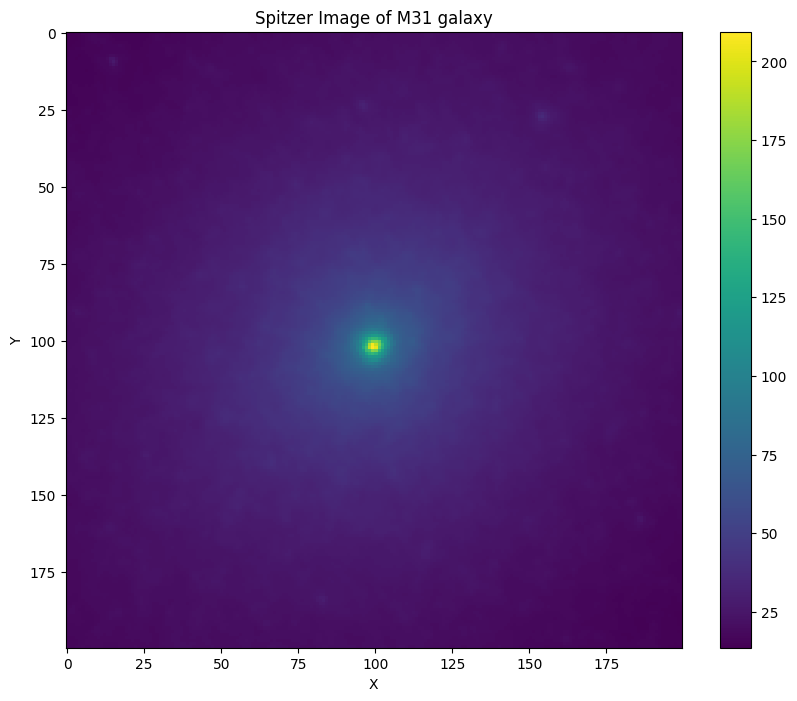

In [ ]:
# Simple image access queries from IRSA for M31 galaxy images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][0]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title('Spitzer Image of M31 galaxy')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

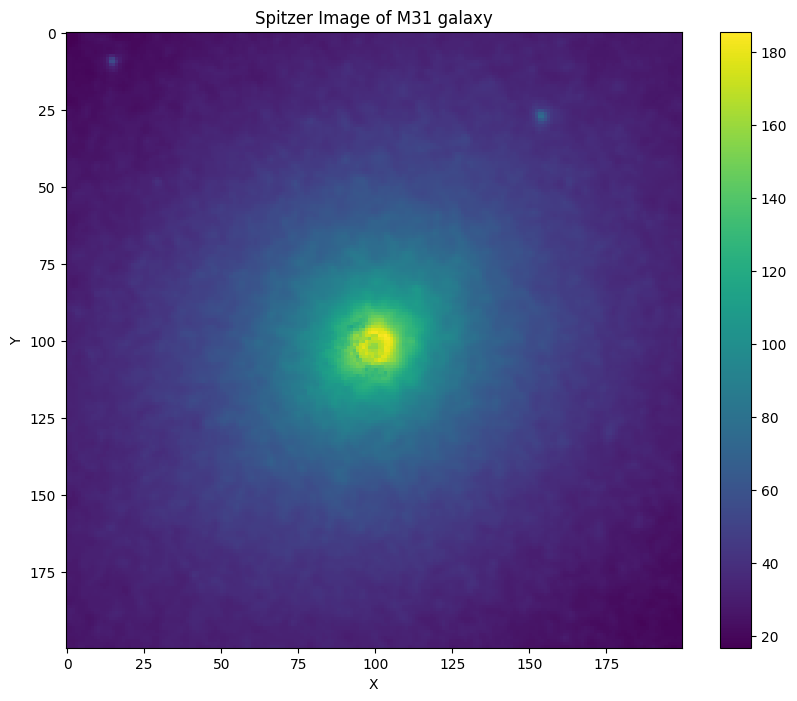

In [ ]:
# Simple image access queries from IRSA for M31 galaxy images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][1]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title('Spitzer Image of M31 galaxy')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

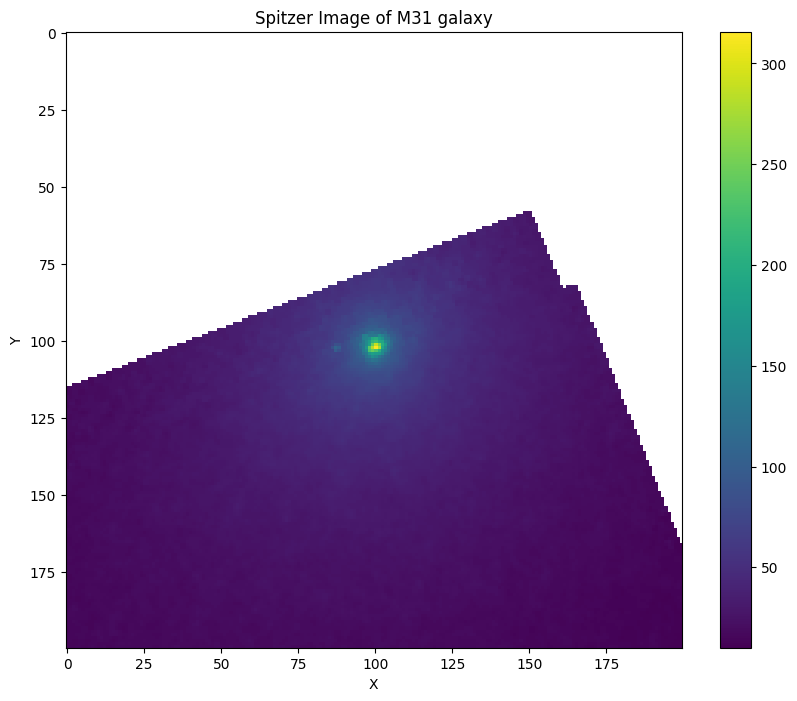

In [ ]:
# Simple image access queries from IRSA for M31 galaxy images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][3]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title('Spitzer Image of M31 galaxy')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
# How many science picture are therein spitzer_images?
science_images_count = len(spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'])
print("Number of science images:", science_images_count)

Number of science images: 32


<ipython-input-75-ded8b8b5d514>:6: DeprecationWarning: the ``irsa`` module has been moved to astroquery.ipac.irsa, please update your imports.
  from astroquery.irsa import Irsa
 [astropy.io.fits.verify]

 [astropy.io.fits.verify]



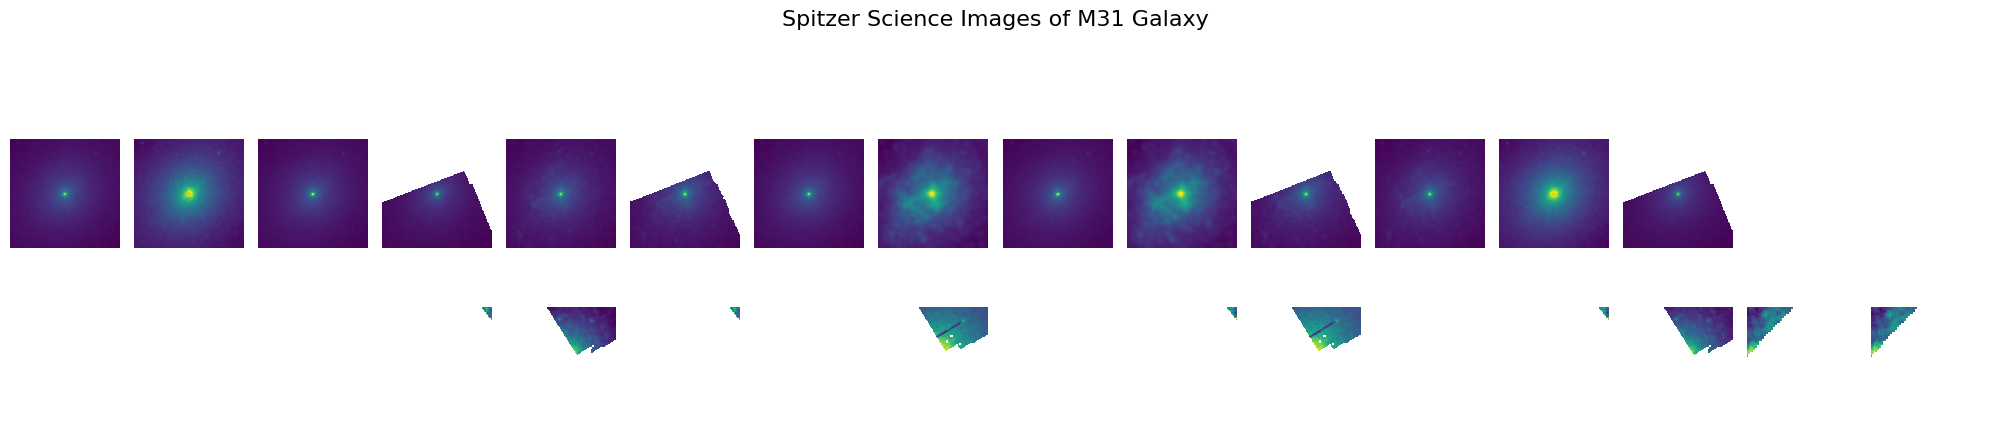

In [ ]:
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
import astropy.units as u
from astroquery.irsa import Irsa
from astropy.coordinates import SkyCoord

# Simple image access queries from IRSA for M31 galaxy images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Filter for science images only
science_images = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science']

# Set up the figure for a 2x16 grid
fig, axes = plt.subplots(2, 16, figsize=(20, 5))  # Adjust figsize as needed for clarity

# Loop through each of the 32 science images
for i in range(32):
    # Access each science image URL
    science_image = science_images[i]
    with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
        cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

    # Plot the cutout in the grid
    ax = axes[i // 16, i % 16]  # Calculate row and column for 2x16 layout
    ax.imshow(cutout.data, cmap='viridis')
    ax.axis('off')  # Hide axes for clarity

plt.suptitle('Spitzer Science Images of M31 Galaxy', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for the title
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
import astropy.units as u
from astroquery.irsa import Irsa
from astropy.coordinates import SkyCoord

# Simple image access queries from IRSA for M31 galaxy images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Filter for science images only
science_images = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science']

# Set up the figure for a 2x16 grid
fig, axes = plt.subplots(16, 2, figsize=(5, 20))  # Adjust figsize as needed for clarity

# Loop through each of the 32 science images
for i in range(32):
    # Access each science image URL
    science_image = science_images[i]
    with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
        cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

    # Plot the cutout in the grid
    ax = axes[i // 16, i % 16]  # Calculate row and column for 2x16 layout
    ax.imshow(cutout.data, cmap='viridis')
    ax.axis('off')  # Hide axes for clarity

plt.suptitle('Spitzer Science Images of M31 Galaxy', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for the title
plt.show()

**Get more details about the file**

In [ ]:
hdul = fits.open(science_image['access_url'], use_fsspec=True)

In [ ]:
# Print the file information
hdul.info()

Filename: <class 'fsspec.implementations.http.HTTPFile'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      77   (4554, 4576)   float32   


In [ ]:
#  Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data
print(primary_hdu.header) # Display the header to learn more about the file
print(repr(hdul[0].header))  # Science data HDU header

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel - floating point                NAXIS   =                    2 / Number of axes                                 NAXIS1  =                 4554 / X axis length                                  NAXIS2  =                 4576 / Y axis length                                  ORIGIN  = 'Spitzer Super-Mosaic Pipeline' / Origin of these image data          CREATOR = 'Spitzer Science Center' / Creator of this FITS file                                                                                                            / TIME AND EXPOSURE INFORMATION                                                                                                                       TELESCOP= 'Spitzer '           / Name of Telescope                              INSTRUME= 'IRAC    '           / Name of Instrument                             CHNLNUM =                    3 / Instrum

**Converting sky coordinates and double check objects**

In [ ]:
# Get skycoordinates of desired object
galaxy = Simbad.query_object('m31')
ra_hms = galaxy['RA'][0]
dec_dms = galaxy['DEC'][0]
print(galaxy)
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

MAIN_ID      RA          DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
          "h:m:s"      "d:m:s"            ...                                                    
------- ------------ ------------ ------- ... -------------- ------------------- ----------------
  M  31 00 42 44.330 +41 16 07.50       7 ...              I 2006AJ....131.1163S                1
RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


In [ ]:
# Convert Right Ascension (RA) and Declination (DEC) to decimal degree
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
ra_deg = coord.ra.deg # round(coord.ra.deg, 2)
dec_deg = coord.dec.deg # round(coord.dec.deg, 2)

print("RA in degrees:", ra_deg)
print("DEC in degrees:", dec_deg)

RA in degrees: 10.684708333333331
DEC in degrees: 41.26875


In [ ]:
# Convert from decimal degree to Right Ascension (RA) and Declination (DEC)
# RA: hours, minutes, seconds. DEC: degrees, arcminutes, arcseconds
# Create a SkyCoord object
coord = SkyCoord(ra=ra_deg, dec=dec_deg, unit='deg', frame='icrs')

# Format RA and DEC with specific style
ra_hms = coord.ra.to_string(unit='hour', sep=' ', precision=3, pad=True)
dec_dms = coord.dec.to_string(unit='deg', sep=' ', precision=2, alwayssign=True, pad=True)

print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


In [ ]:
# Reverse check to see to which object the coordinates belong
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")
object_name = 'MAIN_ID'

M  31


**Appendix: Query IRSA catalogue**

In [ ]:
# Option 1: Display available data by searching for the object name
table = Irsa.query_region("m31", catalog="fp_psc", spatial="Cone",
                          radius=2 * u.arcmin)
print(table)

    ra        dec     err_maj err_min err_ang ... scan_key coadd_key coadd        htm20       
   deg        deg      arcsec  arcsec   deg   ...                                             
---------- ---------- ------- ------- ------- ... -------- --------- ----- -------------------
 10.692216  41.260162    0.10    0.09      87 ...    69157   1590591    33 4805203678124326400
 10.700059  41.263481    0.31    0.30     155 ...    69157   1590591    33 4805203678125364736
 10.699131  41.263248    0.28    0.20      82 ...    69157   1590591    33 4805203678125474304
 10.697569  41.261272    0.11    0.10      90 ...    69157   1590591    33 4805203678125530624
 10.703106  41.252998    0.16    0.14      21 ...    69157   1590591    33 4805203678126695936
 10.703557  41.252811    0.14    0.13     111 ...    69157   1590591    33 4805203678126795776
 10.704491  41.252598    0.15    0.14      24 ...    69157   1590591    33 4805203678126855168
 10.704360  41.257473    0.19    0.19      13 ... 

In [ ]:
coord = SkyCoord(ra_deg, dec_deg, unit='deg', frame='galactic')
table = Irsa.query_region(coordinates=coord,
                          catalog='fp_psc', radius='0d2m0s')
print(table)

    ra        dec     err_maj err_min err_ang ... scan_key coadd_key coadd        htm20       
   deg        deg      arcsec  arcsec   deg   ...                                             
---------- ---------- ------- ------- ------- ... -------- --------- ----- -------------------
237.004404   2.751914    0.27    0.25     179 ...    53725   1235665   150 4803753526738309120
237.003187   2.737467    0.09    0.08       0 ...    53725   1235665   150 4803753526788968960
237.015384   2.732973    0.48    0.33      84 ...    53725   1235665   150 4803753526799783424
236.995817   2.709317    0.07    0.06      11 ...    53724   1235640   127 4803753526822579712


In [ ]:
# Option 2: Display available data by searching using coordinates of galaxy
ra = 121.1743
dec = -21.5733
coord = SkyCoord(ra, dec, unit='deg', frame='galactic')
table = Irsa.query_region(coordinates=coord,
                          catalog='fp_psc', radius='0d2m0s')
print(table)

    ra        dec     err_maj err_min err_ang ... scan_key coadd_key coadd        htm20       
   deg        deg      arcsec  arcsec   deg   ...                                             
---------- ---------- ------- ------- ------- ... -------- --------- ----- -------------------
 10.692216  41.260162    0.10    0.09      87 ...    69157   1590591    33 4805203678124326400
 10.700059  41.263481    0.31    0.30     155 ...    69157   1590591    33 4805203678125364736
 10.699131  41.263248    0.28    0.20      82 ...    69157   1590591    33 4805203678125474304
 10.697569  41.261272    0.11    0.10      90 ...    69157   1590591    33 4805203678125530624
 10.703106  41.252998    0.16    0.14      21 ...    69157   1590591    33 4805203678126695936
 10.703557  41.252811    0.14    0.13     111 ...    69157   1590591    33 4805203678126795776
 10.704491  41.252598    0.15    0.14      24 ...    69157   1590591    33 4805203678126855168
 10.704360  41.257473    0.19    0.19      13 ... 

In [ ]:
Irsa.list_collections()

collection
object
akari_allskymaps
blast
bolocam_gps
bolocam_lh
bolocam_planck_sz
champ
cosmos
euclid_ero
goals


In [ ]:
# Check available catalogs
catalogs = Irsa.list_catalogs()

# Check available catalogs
print(catalogs)

# Filter for Spitzer catalogs
spitzer_catalogs = {key: value for key, value in catalogs.items() if 'spitzer' in key}

# Display the Spitzer catalogs
print(spitzer_catalogs)

{'spitzer.fls_vla': 'Spitzer FLS VLA Image Metadata', 'spitzer.fidel_images': 'Far-Infrared Deep Extragalactic Legacy Survey (FIDEL) Images', 'spitzer.fidel_images_24um': 'Spitzer FIDEL 24um Image Metadata', 'spitzer.fidel_images_70um': 'Spitzer FIDEL 70um Image Metadata', 'spitzer.fidel_images_160um': 'Spitzer FIDEL 160um Image Metadata', 'spitzer.apoglimpse_0_6_images': 'Spitzer APOGlimpse Images', 'spitzer.apoglimpse_1_2_images': 'Spitzer APOGlimpse Images', 'spitzer.glimpsei_0_6': 'Spitzer GlimpseI 0.6 Image Metadata', 'spitzer.glimpsei_1_2': 'Spitzer GlimpseI 1.2 Image Metadata', 'spitzer.glimpseii_0_6': 'Spitzer GlimpseII 0.6 Image Metadata', 'spitzer.glimpseii_1_2': 'Spitzer GlimpseII 1.2 Image Metadata', 'spitzer.glimpseii_sub': 'Spitzer GlimpseII Sub Image Metadata', 'spitzer.glimpse3d_0_6': 'Spitzer Glimpse3d 0.6 Image Metadata', 'spitzer.glimpse3d_1_2': 'Spitzer Glimpse3d 1.2 Image Metadata', 'spitzer.glimpse360_0_6': 'Spitzer Glimpse360 0.6 Image Metadata', 'spitzer.glimpse

In [ ]:
# Convert Right Ascension (RA) and Declination (DEC) to decimal degree from Simbad
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
ra_deg = round(coord.ra.deg, 2)
dec_deg = round(coord.dec.deg, 2)

print("RA in degrees:", ra_deg)
print("DEC in degrees:", dec_deg)

RA in degrees: 10.68
DEC in degrees: 41.27


In [ ]:
# Queries over a polygon
table = Irsa.query_region("m31", catalog="fp_psc", spatial="Polygon",
polygon=[coordinates.SkyCoord(ra=10.1, dec=10.1, unit=(u.deg, u.deg), frame='icrs'),
         coordinates.SkyCoord(ra=10.0, dec=10.1, unit=(u.deg, u.deg), frame='icrs'),
         coordinates.SkyCoord(ra=10.0, dec=10.0, unit=(u.deg, u.deg), frame='icrs')
        ])
print(table)

    ra        dec     err_maj err_min err_ang ... scan_key coadd_key coadd        htm20       
   deg        deg      arcsec  arcsec   deg   ...                                             
---------- ---------- ------- ------- ------- ... -------- --------- ----- -------------------
 10.015839  10.038061    0.09    0.06      90 ...    62740   1443005    91 4805087709670704640
 10.015696  10.099228    0.10    0.07      90 ...    62740   1443005    91 4805087709940635648
 10.011170  10.093903    0.23    0.21     167 ...    62740   1443005    91 4805087710032524288
 10.031016  10.063082    0.19    0.18     114 ...    62740   1443005    91 4805087710169327616
 10.036776  10.060278    0.11    0.06      90 ...    62740   1443005    91 4805087710175392768
 10.059964  10.085445    0.23    0.20      96 ...    62740   1443005    91 4805087710674674176
 10.005549  10.018401    0.16    0.14     108 ...    62740   1443005    91 4805087784811171840


In [ ]:
# Selecting columns
table = Irsa.query_region("m31", catalog="allwise_p3as_psd", spatial="Cone", columns="ra,dec,w1mpro")
print(table)

     ra         dec      w1mpro
    deg         deg       mag  
----------- ----------- -------
 10.6846947  41.2689392   5.819


In [ ]:
# Direct TAP query to the IRSA server
query = ("SELECT TOP 10 ra,dec,j_m,j_msigcom,h_m,h_msigcom,k_m,k_msigcom,ph_qual,cc_flg "
         "FROM fp_psc WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',10.6846947,41.2689392,5.819))=1")
#          "FROM fp_psc WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',202.48417,47.23056,0.4))=1")
results = Irsa.query_tap(query=query).to_qtable()
results

/usr/local/lib/python3.10/dist-packages/pyvo/dal/query.py:325: DALOverflowWarning: Partial result set. Potential causes MAXREC, async storage space, etc.
  warn("Partial result set. Potential causes MAXREC, async storage space, etc.",


ra,dec,j_m,j_msigcom,h_m,h_msigcom,k_m,k_msigcom,ph_qual,cc_flg
deg,deg,mag,mag,mag,mag,mag,mag,,
float64,float64,float32,float32,float32,float32,float32,float32,object,object
17.182749,43.699284,16.484,0.105,15.971,0.145,15.949,0.236,BBD,000
17.198810,43.716602,15.869,0.065,15.295,0.090,15.174,0.123,AAB,000
17.190077,43.718616,14.606,0.031,13.990,0.033,13.763,0.037,AAA,000
17.198377,43.714397,16.412,0.097,15.796,0.138,15.752,0.182,ABC,000
17.174449,43.714855,15.046,0.039,14.365,0.044,14.352,0.063,AAA,000
17.186766,43.715275,15.655,0.059,15.427,0.090,15.548,0.163,AAC,000
17.189046,43.706406,16.128,0.088,15.689,0.111,15.572,0.172,ABC,000
17.205421,43.752987,12.666,0.022,12.145,0.022,12.072,0.021,AAA,000


In [ ]:
# Reverse check if coordinate belong to correct object
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")

M  31


https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html

**Another example**

In [ ]:
# Decimal degrees format for object COSMOS2015 591406
ra_deg = '150.01d'
dec_deg = '2.2d'

In [ ]:
# Convert to traditional dms
coord = SkyCoord(ra=ra_deg, dec=dec_deg, frame='icrs')
ra_hms = coord.ra.to_string(unit='hour', sep=' ', precision=3, pad=True)
dec_dms = coord.dec.to_string(unit='deg', sep=' ', precision=2, alwayssign=True, pad=True)

print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 10 00 02.400
DEC (d:m:s): +02 12 00.00


In [ ]:
# Reverse check to see to which object the coordinates belong
coord = SkyCoord(ra=ra_deg, dec=dec_deg, frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")
object_name = 'MAIN_ID'

COSMOS2015 591406


In [ ]:
object_name = (result['MAIN_ID'][0])
object_name

'COSMOS2015 591406'

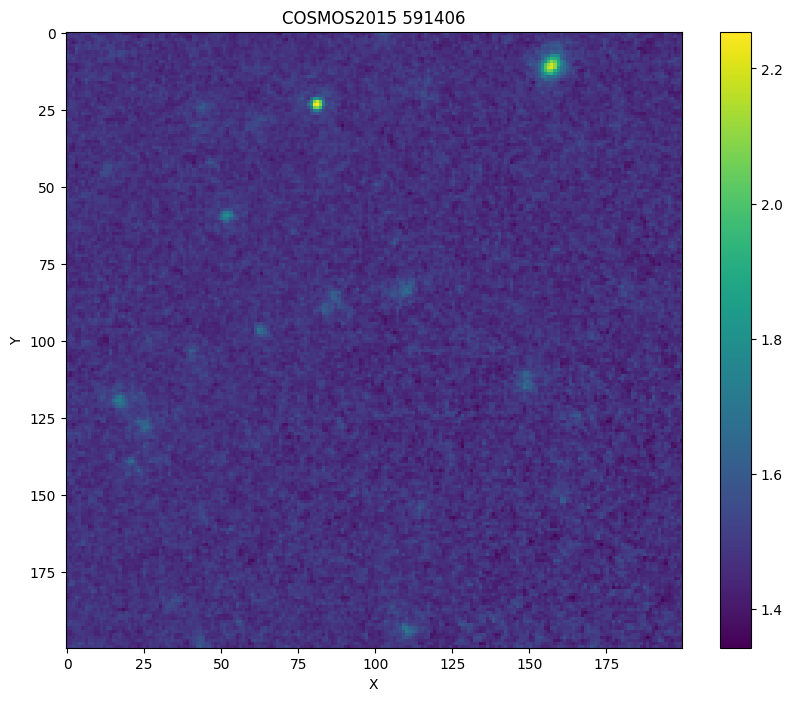

In [ ]:
# Simple image access queries¶
coord = SkyCoord('150.01d 2.2d', frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][0]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title(object_name)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [ ]:
# Example of manually downloading a FITS file if a URL is provided
import requests

url = "URL_to_FITS_file"  # Replace with the actual FITS file URL
response = requests.get(url)
with open("output.fits", "wb") as f:
    f.write(response.content)

# Open the FITS file
with fits.open("output.fits") as hdul:
    hdul.info()  # Display the structure of the FITS file
    data = hdul[0].data  # Access the data